# DINOv3 ViT-B/16 — image features

Loads `weights/dinov3_vitb16_pretrain_lvd1689m.pth` (LVD-1689M pretrain) and runs it on `image.jpg` in the project root.

In [1]:
from pathlib import Path
import torch
from PIL import Image
from torchvision import transforms

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
WEIGHTS = PROJECT_DIR / 'weights' / 'dinov3_vitb16_pretrain_lvd1689m.pth'
IMAGE = PROJECT_DIR / 'image.jpg'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device, WEIGHTS.exists(), IMAGE.exists()

('cuda', True, True)

In [2]:
model = torch.hub.load('facebookresearch/dinov3', 'dinov3_vitb16', pretrained=False)
model.load_state_dict(torch.load(WEIGHTS, map_location='cpu', weights_only=True))
model.eval().to(device);

Using cache found in /home/henrytan/.cache/torch/hub/facebookresearch_dinov3_main


In [3]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

img = Image.open(IMAGE).convert('RGB')
x = transform(img).unsqueeze(0).to(device)
x.shape

torch.Size([1, 3, 224, 224])

In [4]:
with torch.no_grad():
    cls = model(x)
    feats = model.forward_features(x)

print('CLS embedding :', tuple(cls.shape))
print('Patch tokens  :', tuple(feats['x_norm_patchtokens'].shape))
print('CLS L2 norm   :', cls.norm().item())

CLS embedding : (1, 768)
Patch tokens  : (1, 196, 768)
CLS L2 norm   : 17.855592727661133


## PCA visualization of patch features

Project the 768-dim patch tokens to 3 channels and render as RGB — gives a quick visual of what regions the model groups together. Requires `matplotlib` (`uv add matplotlib` if missing).

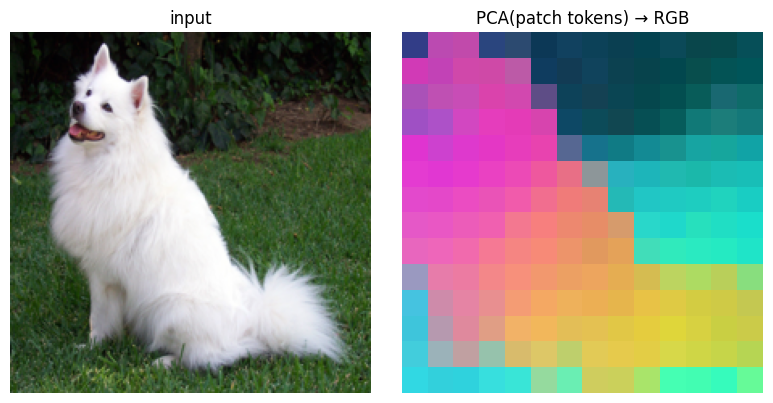

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

patches = feats['x_norm_patchtokens'][0].cpu().numpy()  # (196, 768)
rgb = PCA(n_components=3).fit_transform(patches)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
rgb = rgb.reshape(14, 14, 3)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img.resize((224, 224))); ax[0].set_title('input'); ax[0].axis('off')
ax[1].imshow(rgb); ax[1].set_title('PCA(patch tokens) → RGB'); ax[1].axis('off')
plt.tight_layout()